<a href="https://colab.research.google.com/github/Saikat-too/Machine_Learning/blob/main/Seoul_Bike_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

DataSet

Seoul Bike Sharing Demand. (2020). UCI Machine Learning Repository. https://doi.org/10.24432/C5F62R.




In [ ]:
dataset_cols = ["bike_count","hour","temp","humidity","wind","visibility","dew_pt_tmp","radiation","rain","snow","functional"]

df = pd.read_csv("SeoulBikeData.csv",encoding = 'unicode_escape').drop(["Date","Holiday","Seasons",],axis=1)


In [ ]:
df.columns = dataset_cols
df["functional"] = (df["functional"]=="Yes").astype(int)
df = df[df["hour"]==12]
df = df.drop(["hour"],axis=1)




In [ ]:
df.head()

,bike_count,temp,humidity,wind,visibility,dew_pt_tmp,radiation,rain,snow,functional
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1


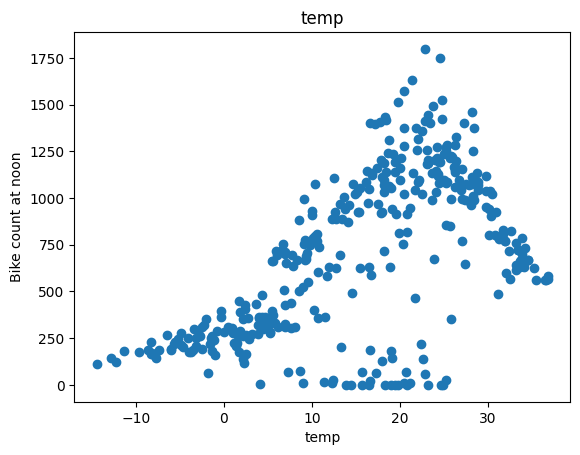

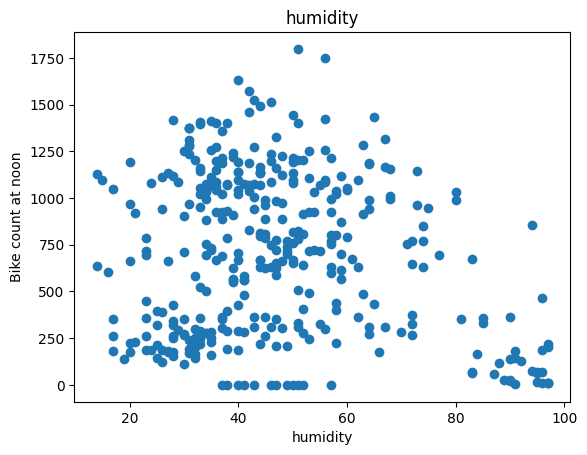

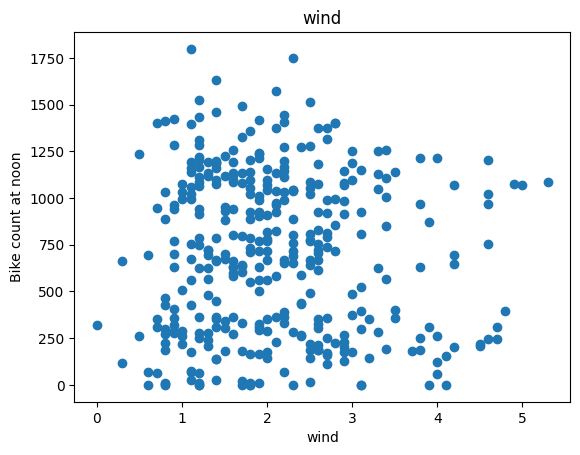

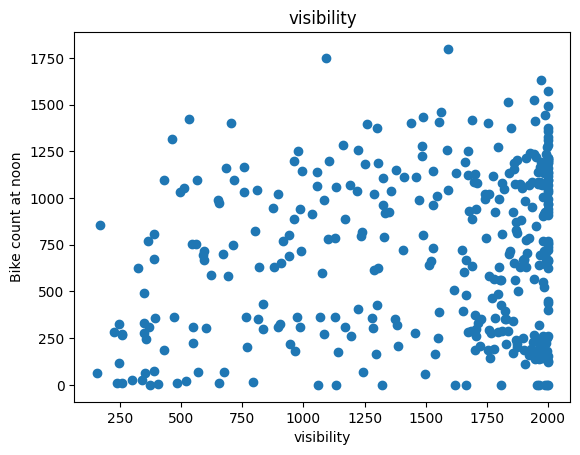

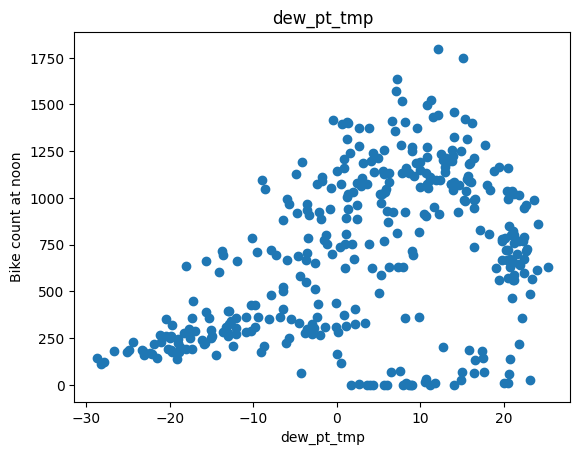

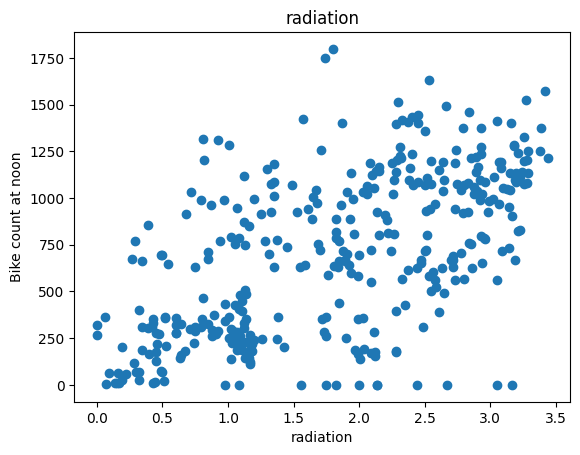

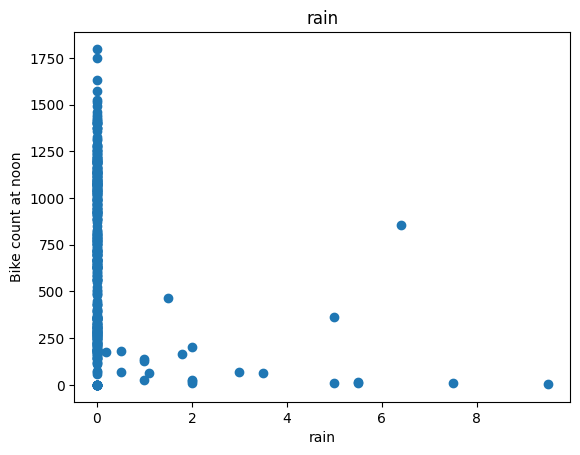

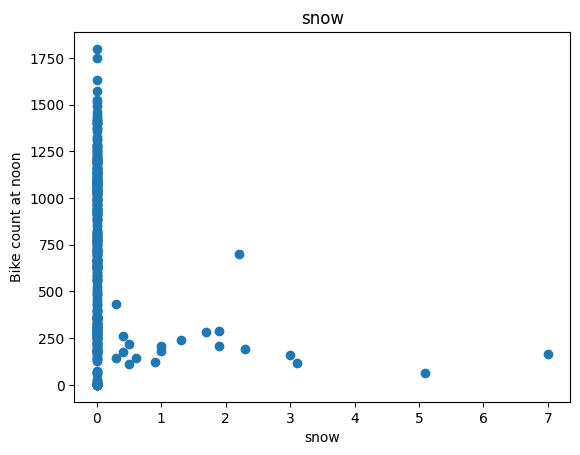

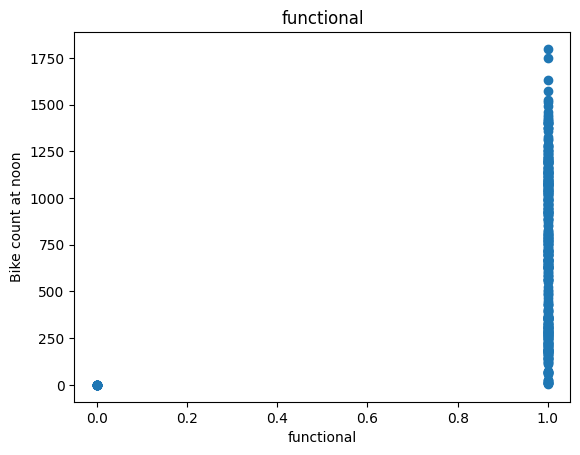

In [ ]:
for label in df.columns[1:]:
  plt.scatter(df[label],df["bike_count"])
  plt.title(label)
  plt.ylabel("Bike count at noon")
  plt.xlabel(label)
  plt.show()

In [ ]:
df = df.drop(["wind","visibility","functional"],axis = 1)
df.head()

,bike_count,temp,humidity,dew_pt_tmp,radiation,rain,snow
12,449,1.7,23,-17.2,1.11,0.0,0.0
36,479,4.3,41,-7.8,1.09,0.0,0.0
60,333,5.8,85,3.4,0.43,0.0,0.0
84,393,-0.3,38,-12.9,1.11,0.0,0.0
108,321,-2.3,25,-19.7,0.00,0.0,0.0


In [ ]:
train , val ,test = np.split(df.sample(frac=1),[int(0.6*len(df)),int(0.8*len(df))])


In [ ]:
def get_xy(dataframe,y_label,x_labels=None):
  dataframe =copy.deepcopy(dataframe)
  if  x_labels is None:
    x = dataframe[[c for c in dataframe.columns if c!=y_label]].values
  else:
    if len(x_labels)==1:
      x = dataframe[x_labels[0]].values.reshape(-1,1)
    else:
      x = dataframe[x_labels].values
  y = dataframe[y_label].values.reshape(-1,1)
  data = np.hstack((x,y))
  return data,x,y



In [ ]:
_,x_train_temp,y_train_temp = get_xy(train,"bike_count",x_labels=["temp"])
_,x_val_temp,y_val_temp = get_xy(val,"bike_count",x_labels=["temp"])
_,x_test_temp,y_test_temp = get_xy(test,"bike_count",x_labels=["temp"])

In [ ]:
temp_reg = LinearRegression()
temp_reg.fit(x_train_temp,y_train_temp)

LinearRegression()

In [ ]:
print(temp_reg.coef_,temp_reg.intercept_)

[[20.52888059]] [355.2321662]


In [ ]:
temp_reg.score(x_test_temp,y_test_temp)

0.2711850930144051

In [ ]:
y_pred_lr=all_reg.predict(x_test_all)

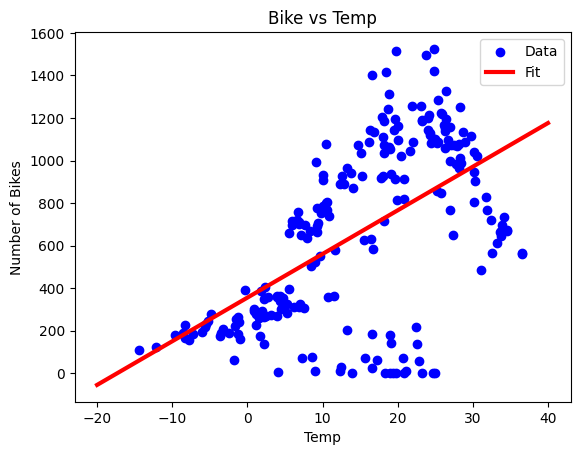

In [ ]:
plt.scatter(x_train_temp,y_train_temp,label="Data",color = "blue")
x=tf.linspace(-20,40,100)
plt.plot(x,temp_reg.predict(np.array(x).reshape(-1,1)),label="Fit",color="red",linewidth=3);
plt.legend()
plt.title("Bike vs Temp")
plt.ylabel("Number of Bikes")
plt.xlabel("Temp")
plt.show()

#Mulitple Linear Regression


In [ ]:
train,val,test = np.split(df.sample(frac=1),[int(0.6*len(df)),int(0.8*len(df))])
_,x_train_all,y_train_all = get_xy(train,"bike_count",x_labels=df.columns[1:])
_,x_val_all,y_val_all = get_xy(val,"bike_count",x_labels=df.columns[1:])
_,x_test_all,y_test_all = get_xy(test,"bike_count",x_labels=df.columns[1:])

In [ ]:
all_reg = LinearRegression()
all_reg.fit(x_train_all,y_train_all)

LinearRegression()

In [ ]:
print(x_train_all.shape)
print(y_train_all.shape)

(219, 6)
(219, 1)


In [ ]:
all_reg.score(x_test_all,y_test_all)

0.1976046310630204

Regression With Neural Net


In [ ]:
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,),axis=None)
temp_normalizer.adapt(x_train_temp.reshape(-1))

In [ ]:
temp_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(1)

    ])

In [ ]:
temp_nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),loss='mean_squared_error')

In [ ]:
def plot_loss(history):
  plt.plot(history.history['loss'],label='loss')
  plt.plot(history.history['val_loss'],label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
history = temp_nn_model.fit(
    x_train_temp.reshape(-1),y_train_temp,
    verbose=0,
    epochs=1000,
    validation_data=(x_val_temp,y_val_temp)
)

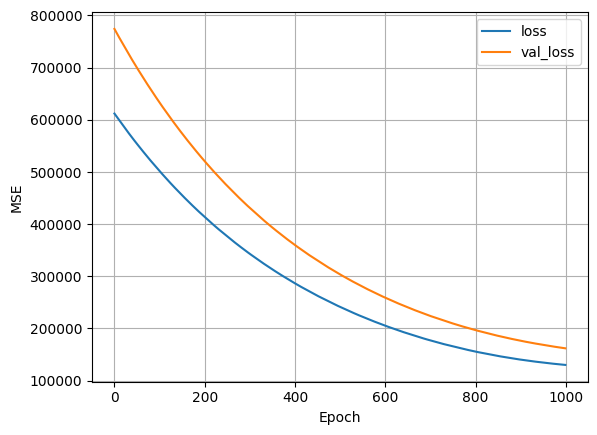

In [ ]:
plot_loss(history)

4/4 [==============================] - 0s 4ms/step


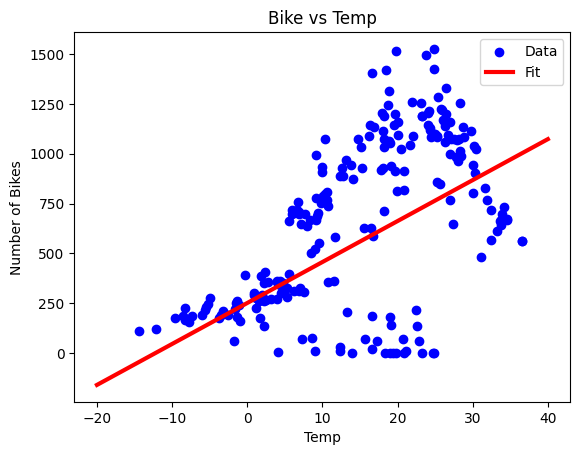

In [ ]:
plt.scatter(x_train_temp,y_train_temp,label="Data",color = "blue")
x=tf.linspace(-20,40,100)
plt.plot(x,temp_nn_model.predict(np.array(x).reshape(-1,1)),label="Fit",color="red",linewidth=3);
plt.legend()
plt.title("Bike vs Temp")
plt.ylabel("Number of Bikes")
plt.xlabel("Temp")
plt.show()

Neural Net

In [ ]:

nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1, activation='relu')
])
nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='mean_squared_error')

In [ ]:
history = nn.model.fit(
    x_train_temp,y_train_temp
)

NameError: name 'nn' is not defined

In [ ]:
history = nn_model.fit(
    x_train_temp,y_train_temp,
    validation_data=(x_val_temp,y_val_temp),
    verbose = 0,epochs= 100
)

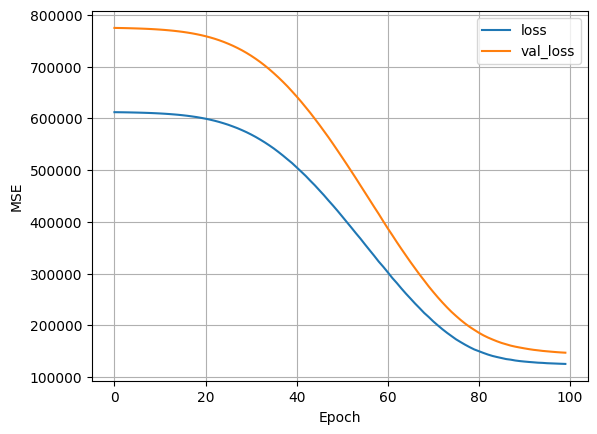

In [ ]:
plot_loss(history)

In [ ]:
all_normalizer = tf.keras.layers.Normalization(input_shape=(6,),axis=-1)
all_normalizer.adapt(x_train_all)

In [ ]:

nn_model = tf.keras.Sequential([
    all_normalizer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1, activation='relu')
])
nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='mean_squared_error')

In [ ]:
history = nn_model.fit(
    x_train_all, y_train_all,
    validation_data=(x_val_all, y_val_all),
    verbose=0, epochs=100,
)

plot_loss(history)

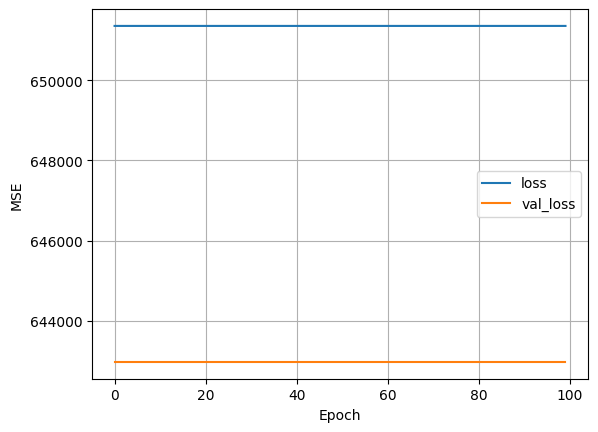

In [ ]:
plot_loss(history)

In [ ]:
y_pred_lr=all_reg.predict(x_test_all)
y_pred_nn=nn_model.predict(x_test_all)

3/3 [==============================] - 0s 4ms/step


In [ ]:
def MSE(y_pred,y_real):
  return (np.square(y_pred-y_real)).mean()

In [ ]:
MSE(y_pred_lr,y_test_all)

153568.44555456957

In [ ]:
MSE(y_pred_nn,y_test_all)

774183.794520548